# NTT

In [3]:
import numpy as np

# Computes (a^b) % m
def power(a, b, m):
  res = 1;
  a = a % m
  while (b > 0):
    if (b % 2 == 1):
      res = (res * a) % m
    a = (a * a) % m
    b = b // 2
  return (res)

# Computes inverse modular multiplicative inverse of a (= x). (a*x)%m = 1
def inv_mod_mul(a, m):
  return (power(a, m-2, m))         # Fermat's Little Theorem (requires m to be prime and a%m!=0)

# A primitive root (g) is a number whose powers (%m) generate all numbers from 1 to p-1
def find_primitive_root(p):
  if (p == 2):
    return (1)
  phi = p - 1
  i = 2
  d = phi
  factors = set()
  # Finds prime factors of phi
  while (d >= i*i):
    if (d % i == 0):
      factors.add(i)
    while (d % i == 0):
      d = d // i
    i += 1
  if (d > 1):
    factors.add(d)
  # Finds the primitive root
  for res in range (2, p):
    is_prim = 1
    for f in factors:
      if(power(res, phi//f, p) == 1):
        is_prim = 0
        break
    if (is_prim):
      return (res)
  return (-1)

# Performs NTT if inv_ntt is False and INTT if inv_ntt is True
# n = 2^q where q is the bit width
def NTT(poly, n, p, root, inv_ntt):
  # Bit reversal
  for i in range (1, n):
    temp = i
    k = n >> 1
    j = 0
    while (k > 0):
      j = (j << 1) | (temp & 1)
      k = k >> 1
      temp = temp >> 1
    if (i < j):
      poly[i], poly[j] = poly[j], poly[i]

  # Cooley-Tukey FFT-like algorithm
  m = 2
  while (m <= n):
    w_m = power(root, (p-1)//m, p)                        # computes w
    if (inv_ntt):
      w_m = inv_mod_mul(w_m, p)

    k = 0
    while (k < n):
      w = 1                                               # w^0
      for j in range (m // 2):
        B_W = (poly[k + j + m//2] * w) % p                # = B.W
        A = poly[k + j]
        poly[k + j] = (A + B_W) % p                       # = A + B.W. store in A array
        poly[k + j + m//2] = (A - B_W + p) % p            # = A - B.W. store in B array
        w = (w * w_m) % p
        # print(w)
      k += m                                              # go to next butterfly of the same stage
    m = m << 1                                            # go to next stage

  # NTT scales the values by n. So for INTT we need to scale down by n
  if (inv_ntt):
    n_inv = inv_mod_mul(n, p)
    for i in range (n):
      poly[i] = (poly[i] * n_inv) % p

  return (poly)

In [4]:
# ************************ Main Function ************************

# Define two polynomials to be multiplied
# F(x) = A0 + A1x^2 + A2x^3 + ...
poly_f = [143, 10, 22, 37, 25]
# G(x) = B0 + B1x^2 + B2x^3 + ...
poly_g = [8, 77, 15, 103]

# NTT parameters
# N must be a power of 2 and greater than the degree of the resulting polynomial
n = 16
# p must be a prime of the form k*N + 1
# we choose a large p so that no coefficient is wrapped around
p = 193                    # (12 * 16 + 1)

prim_root = find_primitive_root(p)

print(f"F(x): {poly_f}")
print(f"G(x): {poly_g}")
print("-" * 30)
print(f"NTT Parameters: n = {n}\tp = {p}")
print(f"Primitive root = {prim_root}")
print("-" * 30)

# Zero padding of polynomials
poly_f.extend([0] * (n - len(poly_f)))
poly_g.extend([0] * (n - len(poly_g)))

# 1. Transform both poly to using NTT
ntt_f = NTT(list(poly_f), n, p, prim_root, 0)
ntt_g = NTT(list(poly_g), n, p, prim_root, 0)

print(f"NTT of F(x): {ntt_f}")
print(f"NTT of G(x): {ntt_g}")

# 2. Performing element-wise multiplication
ntt_res = [(f * g) % p for f, g in zip(ntt_f, ntt_g)]
print(f"NTT of F(x)*G(x): {ntt_res}")
print("-" * 30)

# 3. INTT of ntt_res to get result
poly_res = NTT(ntt_res, n, p, prim_root, 1)

print(f"F(x) * G(x) = {poly_res}")

# Verifiction using std poly multiplication
result = np.polymul(np.flip(poly_f), np.flip(poly_g)) % p
print("Verified result: ")
print(np.flip(result).astype(int))

F(x): [143, 10, 22, 37, 25]
G(x): [8, 77, 15, 103]
------------------------------
NTT Parameters: n = 16	p = 193
Primitive root = 5
------------------------------
NTT of F(x): [44, 10, 170, 102, 17, 33, 120, 114, 143, 48, 169, 171, 82, 101, 13, 179]
NTT of G(x): [10, 116, 19, 26, 169, 168, 134, 67, 36, 32, 76, 106, 10, 102, 189, 26]
NTT of F(x)*G(x): [54, 2, 142, 143, 171, 140, 61, 111, 130, 185, 106, 177, 48, 73, 141, 22]
------------------------------
F(x) * G(x) = [179, 90, 3, 78, 163, 114, 133, 66, 0, 0, 0, 0, 0, 0, 0, 0]
Verified result: 
[179  90   3  78 163 114 133  66]


# SRAM

## HNM

In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def HNM(data, title):
  x1, y1 = data.iloc[:, 0].values, data.iloc[:, 1].values
  x2, y2 = data.iloc[:, 2].values, data.iloc[:, 3].values

  # Rotate 45 degrees
  theta = np.radians(45)
  R = np.array([[np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]])
  R_inv = np.array([[np.cos(-theta), -np.sin(-theta)],
                    [np.sin(-theta),  np.cos(-theta)]])

  rot1 = R @ np.vstack((x1, y1))
  rot2 = R @ np.vstack((x2, y2))

  # Interpolate curves
  x_common = np.linspace(min(rot1[0].min(), rot2[0].min()),
                        max(rot1[0].max(), rot2[0].max()), 1000)
  y1_interp = interp1d(rot1[0], rot1[1], kind='linear', fill_value='extrapolate')(x_common)
  y2_interp = interp1d(rot2[0], rot2[1], kind='linear', fill_value='extrapolate')(x_common)

  # Compute gap → SNM
  gap = y1_interp - y2_interp
  max_index = np.argmax(gap)
  snm_rot = gap[max_index]
  snm = snm_rot/np.sqrt(2)
  snm_x_rot = x_common[max_index]
  y1_rot = y1_interp[max_index]
  y2_rot = y2_interp[max_index]
  y_center = 0.5 * (y1_rot + y2_rot)
  G_half = 0.5 * snm_rot

  print(f"Static Noise Margin (SNM): {snm:.4f} V at rotated X = {snm_x_rot:.5f}")

  # Compute SNM square corners in rotated coordinates
  square_coords_rot = np.array([
      [snm_x_rot, y1_rot],                    # top
      [snm_x_rot + G_half, y_center],         # right
      [snm_x_rot , y2_rot],                   # bottom
      [snm_x_rot - G_half, y_center],         # left
      [snm_x_rot, y1_rot]                     # close the square
  ]).T

  # Rotate square back to original axes
  square_coords = R_inv @ square_coords_rot

  # Plot original butterfly curves
  plt.figure(figsize=(7,7))
  plt.plot(x1, y1, 'g.', label='Curve 1')
  plt.plot(x2, y2, 'r.', label='Curve 2')
  plt.plot(x1, y1, 'g-', alpha=0.5)
  plt.plot(x2, y2, 'r-', alpha=0.5)

  # Plot SNM square
  plt.plot(square_coords[0], square_coords[1], 'k-', linewidth=2, label='SNM Square')

  plt.xlabel('Q')
  plt.ylabel('~Q')
  plt.title(title)
  plt.legend()
  plt.grid(True)
  plt.axis('equal')
  plt.show()


Static Noise Margin (SNM): 0.3436 V at rotated X = 0.35738


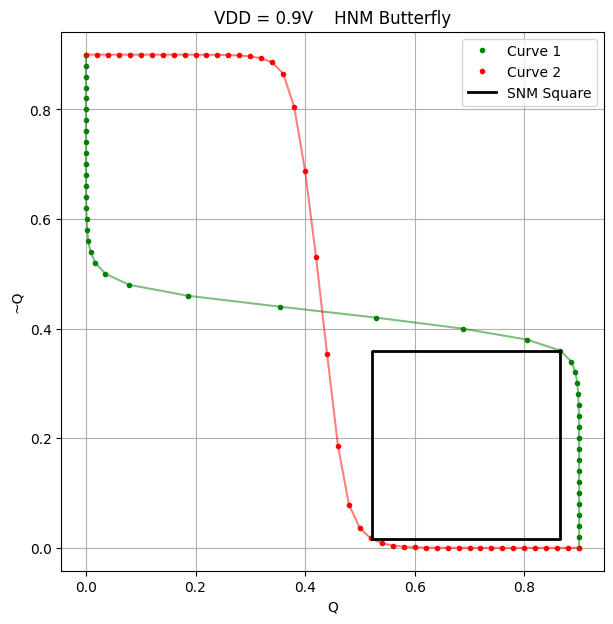

In [ ]:
data = pd.read_csv('/content/HNM.csv')

HNM(data, 'VDD = 0.9V    HNM Butterfly')

## RNM

In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def RNM(data, title):
    # load curves: (Q, Qbar) for two lobes
    x1, y1 = data.iloc[:, 0].values, data.iloc[:, 1].values
    x2, y2 = data.iloc[:, 2].values, data.iloc[:, 3].values

    # 45° rotation matrix
    theta = np.radians(45)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    R_inv = np.array([[np.cos(-theta), -np.sin(-theta)],
                      [np.sin(-theta),  np.cos(-theta)]])

    # Rotate both lobes
    rot1 = R @ np.vstack((x1, y1))
    rot2 = R @ np.vstack((x2, y2))

    # Sort by rotated-x because interp1d requires monotonic x
    idx1 = np.argsort(rot1[0])
    idx2 = np.argsort(rot2[0])
    x1r, y1r = rot1[0][idx1], rot1[1][idx1]
    x2r, y2r = rot2[0][idx2], rot2[1][idx2]

    # Determine overlap range (important to avoid extrapolation)
    x_min = max(x1r.min(), x2r.min())
    x_max = min(x1r.max(), x2r.max())
    if x_max <= x_min:
        raise ValueError("No overlap between rotated lobes — check your butterfly data or rotation.")

    # build common x only inside overlap
    x_common = np.linspace(x_min, x_max, 2000)

    # Interpolate (no extrapolation now)
    y1_interp = interp1d(x1r, y1r, kind='linear', bounds_error=False, fill_value=np.nan)(x_common)
    y2_interp = interp1d(x2r, y2r, kind='linear', bounds_error=False, fill_value=np.nan)(x_common)

    # If any NaNs appear, shrink domain to where both are finite
    valid = np.isfinite(y1_interp) & np.isfinite(y2_interp)
    if not np.any(valid):
        raise ValueError("No valid overlapping interpolation region after trimming - check sampling density.")
    x_common = x_common[valid]
    y1_interp = y1_interp[valid]
    y2_interp = y2_interp[valid]

    # Compute gap as top - bottom at each x (makes function independent of which curve is y1 or y2)
    top = np.maximum(y1_interp, y2_interp)
    bottom = np.minimum(y1_interp, y2_interp)
    gap = top - bottom

    # find maximum gap -> rotated SNM
    max_index = np.argmax(gap)
    snm_rot = gap[max_index]
    snm = snm_rot / np.sqrt(2)   # convert back to volts

    # geometry for square (use the local top and bottom at max_index)
    snm_x_rot = x_common[max_index]
    y_top_rot = top[max_index]
    y_bottom_rot = bottom[max_index]
    y_center = 0.5 * (y_top_rot + y_bottom_rot)
    G_half = 0.5 * snm_rot

    print(f"SNM: {snm:.4f} V at rotated X = {snm_x_rot:.5f}")

    # Square coords in rotated domain
    square_coords_rot = np.array([
        [snm_x_rot, y_top_rot],                   # top
        [snm_x_rot + G_half, y_center],           # right
        [snm_x_rot, y_bottom_rot],                # bottom
        [snm_x_rot - G_half, y_center],           # left
        [snm_x_rot, y_top_rot]                    # close
    ]).T

    # rotate back
    square_coords = R_inv @ square_coords_rot

    # Plot original butterfly curves (original axes)
    plt.figure(figsize=(7,7))
    plt.plot(x1, y1, 'g.', label='Curve 1')
    plt.plot(x2, y2, 'r.', label='Curve 2')
    plt.plot(x1, y1, 'g-', alpha=0.5)
    plt.plot(x2, y2, 'r-', alpha=0.5)
    plt.plot(square_coords[0], square_coords[1], 'k-', linewidth=2, label='SNM Square')

    plt.xlabel('Q')
    plt.ylabel('~Q')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

    return snm


SNM: 0.1406 V at rotated X = -0.35715


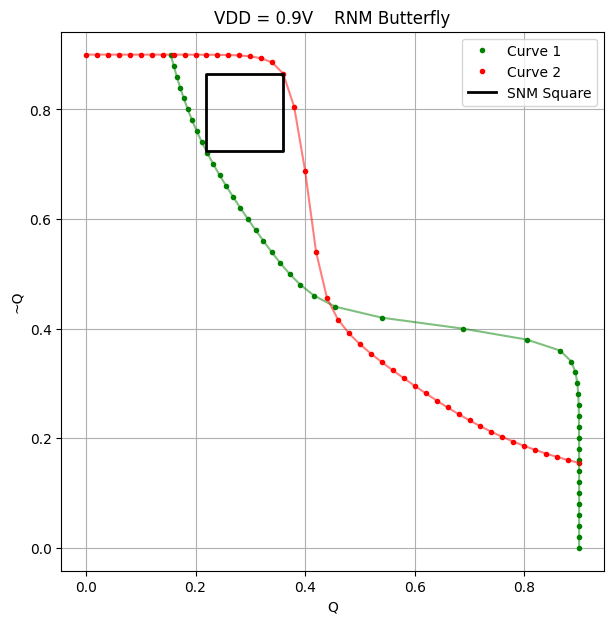

np.float64(0.1406045991172264)

In [ ]:
data = pd.read_csv('/content/RNM.csv')

RNM(data, 'VDD = 0.9V    RNM Butterfly')